In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('ConcreteStrengthDataset.csv')
df.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age_days,compressive_strength_mpa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [ ]:
print(f'Dataset Shape: {df.shape}')

Naame: Sedra Alramadan, ID: 2231165115, Dataset Shape: (1005, 9)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cement                    1005 non-null   float64
 1   blast_furnace_slag        1005 non-null   float64
 2   fly_ash                   1005 non-null   float64
 3   water                     1005 non-null   float64
 4   superplasticizer          1005 non-null   float64
 5   coarse_aggregate          1005 non-null   float64
 6   fine_aggregate            1005 non-null   float64
 7   age_days                  1005 non-null   int64  
 8   compressive_strength_mpa  1005 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 70.8 KB


In [ ]:
df.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age_days,compressive_strength_mpa
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,278.629055,72.043134,55.535075,182.074378,6.031647,974.376468,772.686617,45.856716,35.250273
std,104.345003,86.170555,64.207448,21.340740,5.919559,77.579534,80.339851,63.734692,16.284808
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,190.680000,0.000000,0.000000,166.610000,0.000000,932.000000,724.300000,7.000000,23.523542
50%,265.000000,20.000000,0.000000,185.700000,6.100000,968.000000,780.000000,28.000000,33.798114
75%,349.000000,142.500000,118.270000,192.940000,10.000000,1031.000000,822.200000,56.000000,44.868340
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [ ]:
print(f'Missing value count: {df.isna().sum().sum()}')
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing value count: 0
Duplicate rows: 0


In [ ]:
X = df.drop(columns ='compressive_strength_mpa')
y = df['compressive_strength_mpa']
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (1005, 8)
y shape: (1005,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)
print("Training target shape :", y_train.shape)
print("Testing target shape  :", y_test.shape)

Training feature shape: (804, 8)
Testing feature shape : (201, 8)
Training target shape : (804,)
Testing target shape  : (201,)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Regression model evaluation metrics
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return pd.Series({
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled , y_train)
linear_predictions = linear_model.predict(X_test_scaled)
linear_results = regression_metrics(y_test, linear_predictions)

print("Linear Regression test-set metrics:")
display(linear_results.to_frame(name="value"))

Linear Regression test-set metrics:


,value
MAE,8.896028
MSE,125.265338
RMSE,11.192200
R2,0.580109


In [ ]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled , y_train)
ridge_predictions = ridge_model.predict(X_test_scaled)
ridge_results = regression_metrics(y_test, ridge_predictions)

print("Ridge Regression test-set metrics:")
display(ridge_results.to_frame(name="value"))

Ridge Regression test-set metrics:


,value
MAE,8.898277
MSE,125.310911
RMSE,11.194236
R2,0.579956


In [ ]:
knn_model = KNeighborsRegressor(n_neighbors=7)
knn_model.fit(X_train_scaled , y_train)
knn_predictions = knn_model.predict(X_test_scaled)
knn_results = regression_metrics(y_test, knn_predictions)

print("KNN Regression test-set metrics:")
display(knn_results.to_frame(name="value"))

KNN Regression test-set metrics:


,value
MAE,7.532200
MSE,93.487351
RMSE,9.668886
R2,0.686629


In [ ]:
dt_model = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_model.fit(X_train , y_train)
dt_predictions = dt_model.predict(X_test)
dt_results = regression_metrics(y_test, dt_predictions)

print("Decision Tree Regression test-set metrics:")
display(dt_results.to_frame(name="value"))

Decision Tree Regression test-set metrics:


,value
MAE,5.922499
MSE,61.565317
RMSE,7.846357
R2,0.793632


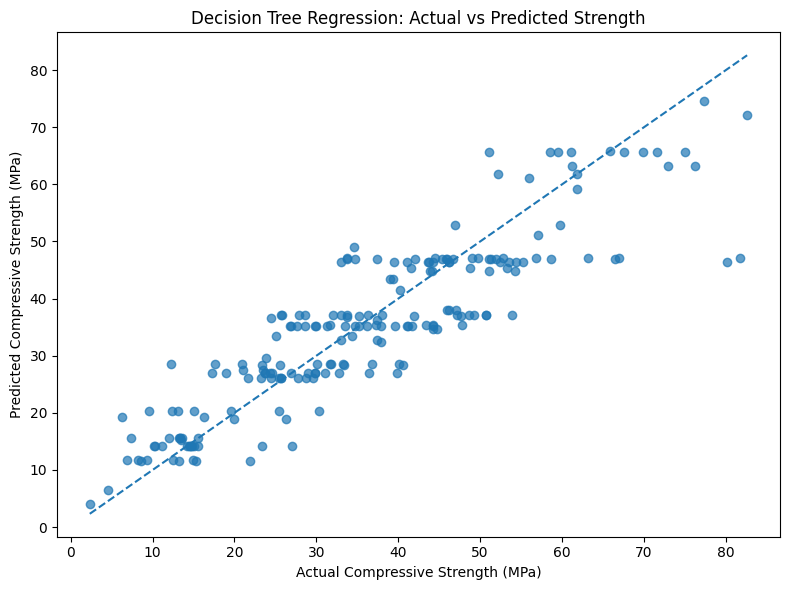

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, dt_predictions, alpha=0.7)

line_min = min(y_test.min(), dt_predictions.min())
line_max = max(y_test.max(), dt_predictions.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")

plt.title("Decision Tree Regression: Actual vs Predicted Strength")
plt.xlabel("Actual Compressive Strength (MPa)")
plt.ylabel("Predicted Compressive Strength (MPa)")
plt.tight_layout()
plt.show()


In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(dt_model, X, y , cv=cv, scoring='r2',return_train_score=False)
print("5-fold cross-validation summary:")
print(f'CV R2 results: {cv_results['test_score']}')
print(f"Mean R2: {cv_results['test_score'].mean():.3f}")

5-fold cross-validation summary:
CV R2 results: [0.79363223 0.82012268 0.80649295 0.75876053 0.81136548]
Mean R2: 0.798


In [ ]:
comp_table = pd.DataFrame(
    { 'Model': ['Linear Regression', 'Ridge Regression', 'K-Neighbours regressor', 'Decision Tree regressor'],
      'MAE': [linear_results['MAE'], ridge_results['MAE'], knn_results['MAE'], dt_results['MAE']],
      'MSE': [linear_results['MSE'], ridge_results['MSE'], knn_results['MSE'], dt_results['MSE']],
      'RMSE': [linear_results['RMSE'], ridge_results['RMSE'], knn_results['RMSE'], dt_results['RMSE']],
      'R2': [linear_results['R2'], ridge_results['R2'], knn_results['R2'], dt_results['R2']]
    }
)

comp_table

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,8.896028,125.265338,11.192200,0.580109
1,Ridge Regression,8.898277,125.310911,11.194236,0.579956
2,K-Neighbours regressor,7.532200,93.487351,9.668886,0.686629
3,Decision Tree regressor,5.922499,61.565317,7.846357,0.793632


Based on multiple evaluation metrics from the results comparison table, the decision tree regressor had the best performance, it had the lowest error and the highest R2 values. Multiple evaluation metrics should be considered for regression because it makes the performance more reliable because it shows the average error for each prediction and how much variance in the target variable is explained by the model.